# Notebook 00 — Edibility Map Analysis

Analyze the LLM-generated `species_edibility_map.csv` together with the DF20-Mini image metadata to characterize the classification problem.

## Why we're doing this

The 179 species in DF20-Mini need to be aggregated into user-facing edibility categories. Before committing to a classification scheme, we verify that:

1. The proposed categories have adequate training support
2. Per-genus distributions tell a coherent story
3. The `unknown` category (species with disputed literature) is large enough to be a meaningful class on its own

The output of this notebook motivates the 4-class scheme used in Notebook 2.

## Proposed 4-class scheme

| Label | Meaning | User interaction |
|---|---|---|
| **SAFE** | Edible raw and cooked | Safe to collect |
| **COOK_FIRST** | Edible when properly cooked, toxic raw | Warning to cook |
| **AVOID** | Confirmed toxic or inedible | Do not eat |
| **UNCERTAIN** | Literature disagrees / insufficient documentation | Do not eat; **flag for research** |

The UNCERTAIN category is explicitly surfaced to the user — not hidden. This turns ambiguous species into a signal for downstream research rather than noise.


In [1]:
# ==================== IMPORTS ====================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# ==================== CONFIG ====================
ARTIFACTS_DIR    = Path('artifacts')
EDIBILITY_CSV    = ARTIFACTS_DIR / 'species_edibility_map.csv'
METADATA_CSV     = ARTIFACTS_DIR / 'df20m_metadata.csv'
OUTPUT_FIG_DIR   = Path('results/figures')
OUTPUT_FIG_DIR.mkdir(exist_ok=True, parents=True)

# Consistent colors for bucket visualizations
BUCKET_COLORS = {
    'SAFE':       '#2ca02c',   # green
    'COOK_FIRST': '#ff7f0e',   # orange
    'AVOID':      '#d62728',   # red
    'UNCERTAIN':  '#7f7f7f',   # gray
}
BUCKET_ORDER = ['SAFE', 'COOK_FIRST', 'AVOID', 'UNCERTAIN']

## Step 1 — Load and Assign Buckets

Map each species to one of the 4 user-facing buckets based on its `edibility_cooked` label from the LLM annotation.

**Mapping rule**:

| LLM output (`edibility_cooked`) | Bucket |
|---|---|
| `edible` | SAFE |
| `edible_cooked_only` | COOK_FIRST |
| `poisonous`, `deadly`, `inedible` | AVOID |
| `unknown` | UNCERTAIN |


In [3]:
edib = pd.read_csv(EDIBILITY_CSV)
edib['genus'] = edib['species'].str.split().str[0]

def assign_bucket(cooked_label):
    if cooked_label == 'edible':
        return 'SAFE'
    elif cooked_label == 'edible_cooked_only':
        return 'COOK_FIRST'
    elif cooked_label == 'unknown':
        return 'UNCERTAIN'
    else:  # poisonous, deadly, inedible
        return 'AVOID'

edib['bucket'] = edib['edibility_cooked'].apply(assign_bucket)

print(f"Total species: {len(edib)}")
print(f"\nBucket distribution (species level):")
for b in BUCKET_ORDER:
    n = (edib['bucket'] == b).sum()
    print(f"  {b:12s} {n:4d} species ({100*n/len(edib):5.1f}%)")

Total species: 179

Bucket distribution (species level):
  SAFE           21 species ( 11.7%)
  COOK_FIRST     37 species ( 20.7%)
  AVOID          96 species ( 53.6%)
  UNCERTAIN      25 species ( 14.0%)


## Step 2 — Per-Genus Distribution

Which genera contribute to which bucket? This reveals whether the classification problem is "genus-level easy" (a genus uniformly maps to one bucket) or "species-level hard" (the genus has mixed buckets and the model must distinguish within-genus).

In [4]:
contingency = pd.crosstab(edib['genus'], edib['bucket'])
# Reorder columns
contingency = contingency.reindex(columns=BUCKET_ORDER, fill_value=0)
contingency['total'] = contingency.sum(axis=1)
print("Species count per genus × bucket:")
print(contingency)

# Flag easy vs hard genera
print("\nGenus difficulty classification:")
for g in contingency.index:
    row = contingency.loc[g, BUCKET_ORDER]
    n_buckets = (row > 0).sum()
    if n_buckets == 1:
        difficulty = 'UNIFORM (trivial to classify)'
    elif n_buckets == 2:
        difficulty = '2-WAY'
    else:
        difficulty = f'{n_buckets}-WAY (hard)'
    dominant = BUCKET_ORDER[row.values.argmax()]
    print(f"  {g:10s} {difficulty:25s} dominant={dominant}")

Species count per genus × bucket:
bucket     SAFE  COOK_FIRST  AVOID  UNCERTAIN  total
genus                                               
Agaricus     11           2      3          5     21
Amanita       0           7      9          1     17
Boletus       4           2      0          0      6
Clitocybe     0           1      9          3     13
Mycena        0           0     49          0     49
Russula       6          25     26         16     73

Genus difficulty classification:
  Agaricus   4-WAY (hard)              dominant=SAFE
  Amanita    3-WAY (hard)              dominant=AVOID
  Boletus    2-WAY                     dominant=SAFE
  Clitocybe  3-WAY (hard)              dominant=AVOID
  Mycena     UNIFORM (trivial to classify) dominant=AVOID
  Russula    4-WAY (hard)              dominant=AVOID


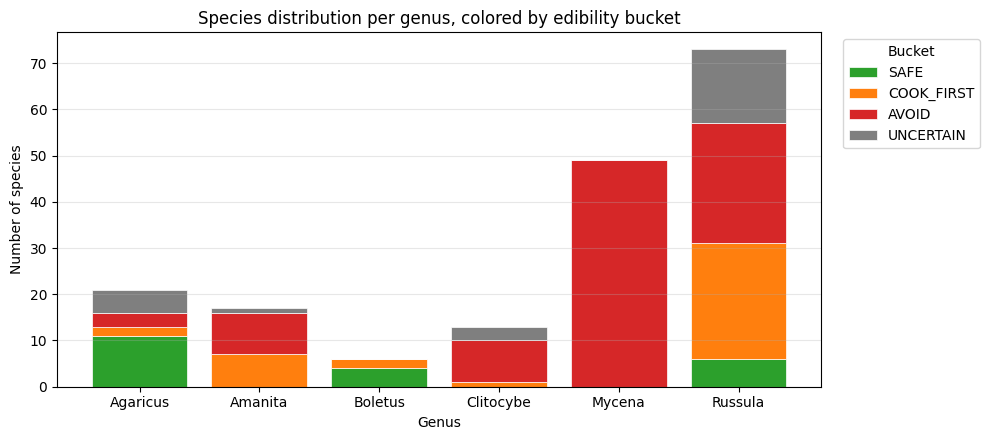

In [5]:
# Stacked bar chart: per-genus composition
fig, ax = plt.subplots(figsize=(10, 4.5))
bottom = np.zeros(len(contingency))
for b in BUCKET_ORDER:
    ax.bar(
        contingency.index, contingency[b],
        bottom=bottom, label=b, color=BUCKET_COLORS[b],
        edgecolor='white', linewidth=0.5,
    )
    bottom += contingency[b].values
ax.set_xlabel('Genus')
ax.set_ylabel('Number of species')
ax.set_title('Species distribution per genus, colored by edibility bucket')
ax.legend(title='Bucket', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_DIR / 'species_per_genus_bucket.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3 — Image-Level Distribution

Species counts are one thing; image counts are what the classifier actually sees. Because DF20-Mini has a heavy long tail (39x imbalance between most and least common species), the image-level and species-level distributions can differ.

Join the edibility map to `df20m_metadata.csv` (from Notebook 1) to get per-image bucket labels.

In [6]:
metadata = pd.read_csv(METADATA_CSV)
print(f"Total images in metadata: {len(metadata):,}")

# Merge edibility → per-image bucket
species_to_bucket = dict(zip(edib['species'], edib['bucket']))
metadata['bucket'] = metadata['species'].map(species_to_bucket)

# Any species in metadata missing from edibility map?
missing = metadata['bucket'].isna().sum()
if missing > 0:
    print(f"\nWARNING: {missing} images have species not in edibility map:")
    print(metadata[metadata['bucket'].isna()]['species'].value_counts().head())
    metadata['bucket'] = metadata['bucket'].fillna('UNCERTAIN')

print(f"\nImage-level bucket distribution:")
for b in BUCKET_ORDER:
    n = (metadata['bucket'] == b).sum()
    print(f"  {b:12s} {n:7,d} images ({100*n/len(metadata):5.1f}%)")

# Train vs test balance
print(f"\nBucket × split breakdown:")
print(metadata.pivot_table(
    index='bucket', columns='split', aggfunc='size', fill_value=0
).reindex(BUCKET_ORDER))

Total images in metadata: 36,361

Image-level bucket distribution:
  SAFE           5,444 images ( 15.0%)
  COOK_FIRST     7,639 images ( 21.0%)
  AVOID         20,725 images ( 57.0%)
  UNCERTAIN      2,553 images (  7.0%)

Bucket × split breakdown:
split       test  train
bucket                 
SAFE         546   4898
COOK_FIRST   764   6875
AVOID       2073  18652
UNCERTAIN    254   2299


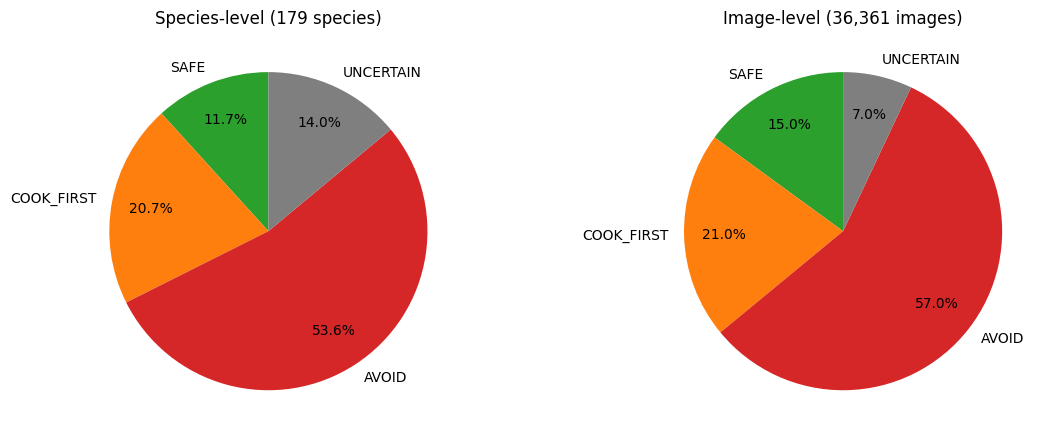

In [7]:
# Side-by-side pie: species vs image level
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

species_counts = edib['bucket'].value_counts().reindex(BUCKET_ORDER, fill_value=0)
image_counts   = metadata['bucket'].value_counts().reindex(BUCKET_ORDER, fill_value=0)

for ax, counts, title in [
    (axes[0], species_counts, f'Species-level ({len(edib)} species)'),
    (axes[1], image_counts,   f'Image-level ({len(metadata):,} images)'),
]:
    colors = [BUCKET_COLORS[b] for b in counts.index]
    wedges, texts, autotexts = ax.pie(
        counts.values, labels=counts.index, colors=colors,
        autopct='%.1f%%', startangle=90, pctdistance=0.75,
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig(OUTPUT_FIG_DIR / 'species_vs_image_bucket_pie.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 4 — Long-Tail Within Each Bucket

Within each bucket, how are images distributed across species? A bucket with a single dominant species is "easy" — the model just needs to recognize that species. A bucket with many small species is hard because each species gets few training examples.

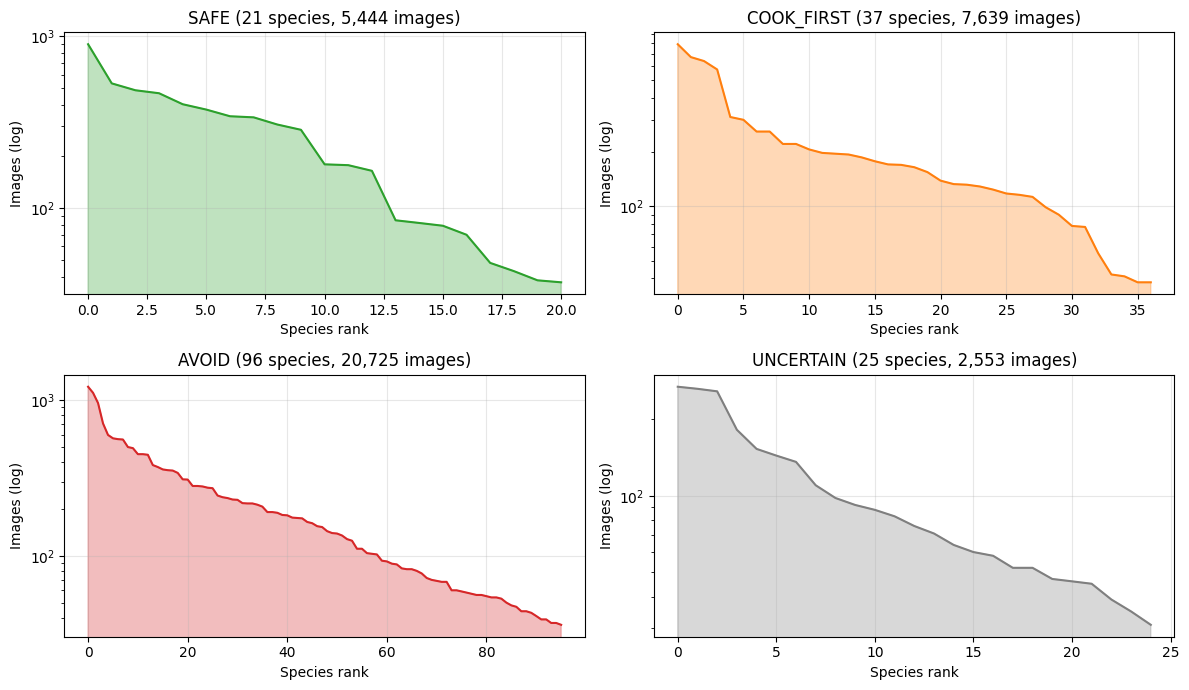

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, b in zip(axes.flat, BUCKET_ORDER):
    species_in_bucket = edib[edib['bucket'] == b]['species'].values
    per_species_counts = (
        metadata[metadata['species'].isin(species_in_bucket)]
        .groupby('species').size()
        .sort_values(ascending=False)
    )
    if len(per_species_counts) > 0:
        ax.plot(range(len(per_species_counts)), per_species_counts.values,
                color=BUCKET_COLORS[b], linewidth=1.5)
        ax.fill_between(range(len(per_species_counts)), per_species_counts.values,
                        color=BUCKET_COLORS[b], alpha=0.3)
        ax.set_yscale('log')
    ax.set_title(f"{b} ({len(per_species_counts)} species, {per_species_counts.sum():,} images)")
    ax.set_xlabel('Species rank')
    ax.set_ylabel('Images (log)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIG_DIR / 'long_tail_per_bucket.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 5 — Internal Structure of AVOID

AVOID is the largest bucket and internally heterogeneous — it combines deadly, moderately poisonous, and merely inedible species. Understanding this sub-structure matters for:

1. **Report framing** — "half of AVOID is actually mild/inedible, not dangerous"
2. **Future cost-sensitive AL** — if we later want to separate "deadly" from "mildly toxic" for differential user warnings, we can do so without rebuilding the label set

AVOID: 96 species, 20,725 images

Breakdown by original LLM label:
edibility_cooked
poisonous    52
inedible     42
deadly        2
Name: count, dtype: int64

Breakdown by toxicity level:
toxicity_level
1    43
2    46
3     5
5     2
dtype: int64


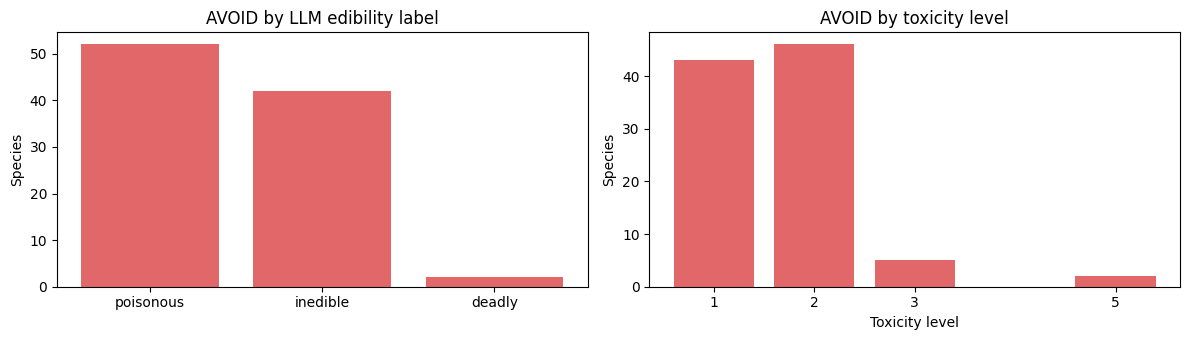

In [9]:
avoid = edib[edib['bucket'] == 'AVOID']
print(f"AVOID: {len(avoid)} species, {len(metadata[metadata['bucket']=='AVOID']):,} images\n")

print("Breakdown by original LLM label:")
print(avoid['edibility_cooked'].value_counts())

print("\nBreakdown by toxicity level:")
tox_counts = avoid.groupby('toxicity_level').size()
print(tox_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].bar(avoid['edibility_cooked'].value_counts().index,
            avoid['edibility_cooked'].value_counts().values, color='#d62728', alpha=0.7)
axes[0].set_title('AVOID by LLM edibility label')
axes[0].set_ylabel('Species')

axes[1].bar(tox_counts.index, tox_counts.values, color='#d62728', alpha=0.7)
axes[1].set_xlabel('Toxicity level')
axes[1].set_ylabel('Species')
axes[1].set_title('AVOID by toxicity level')
axes[1].set_xticks(sorted(tox_counts.index))

plt.tight_layout()
plt.savefig(OUTPUT_FIG_DIR / 'avoid_internal_structure.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 6 — What's in UNCERTAIN?

UNCERTAIN is our motivating "research signal" category. Confirm it's a meaningful category — not just a dumping ground — by examining:

- Which genera contribute to it
- Whether the LLM flagged them with `low` confidence (suggesting genuine ambiguity, not annotator laziness)

In [10]:
unc = edib[edib['bucket'] == 'UNCERTAIN']
print(f"UNCERTAIN: {len(unc)} species, {len(metadata[metadata['bucket']=='UNCERTAIN']):,} images\n")

print("By genus:")
print(unc['genus'].value_counts())

print("\nBy LLM confidence:")
print(unc['confidence'].value_counts())

print("\nAll UNCERTAIN species with their notes:")
for _, row in unc.iterrows():
    print(f"  {row['species']:35s}  [{row['confidence']:6s}]  {row['notes']}")

UNCERTAIN: 25 species, 2,553 images

By genus:
genus
Russula      16
Agaricus      5
Clitocybe     3
Amanita       1
Name: count, dtype: int64

By LLM confidence:
confidence
low       24
medium     1
Name: count, dtype: int64

All UNCERTAIN species with their notes:
  Agaricus brunneolus                  [low   ]  Poorly documented edibility; insufficient data in major references
  Agaricus cupreobrunneus              [low   ]  Insufficient documentation in authoritative references
  Agaricus dulcidulus                  [low   ]  Small species; edibility insufficiently documented
  Agaricus subfloccosus                [low   ]  Confusion risk with toxic Agaricus spp.; insufficient data
  Agaricus subperonatus                [low   ]  Poorly documented; insufficient literature for safe classification
  Amanita strobiliformis               [medium]  Edibility uncertain; some toxicity suspected; best avoided
  Clitocybe costata                    [low   ]  Ribbed Funnel; edibility insuffi

## Step 7 — LLM Confidence Distribution

How confident was the LLM across buckets? If SAFE / COOK_FIRST are dominated by `high` confidence and UNCERTAIN is dominated by `low` confidence, that's the expected pattern — it validates UNCERTAIN as a distinct epistemic category, not just noise.

LLM confidence per bucket (% within each bucket):
confidence  high   low  medium
bucket                        
SAFE        81.0   0.0    19.0
COOK_FIRST  29.7   0.0    70.3
AVOID       19.8  42.7    37.5
UNCERTAIN    0.0  96.0     4.0


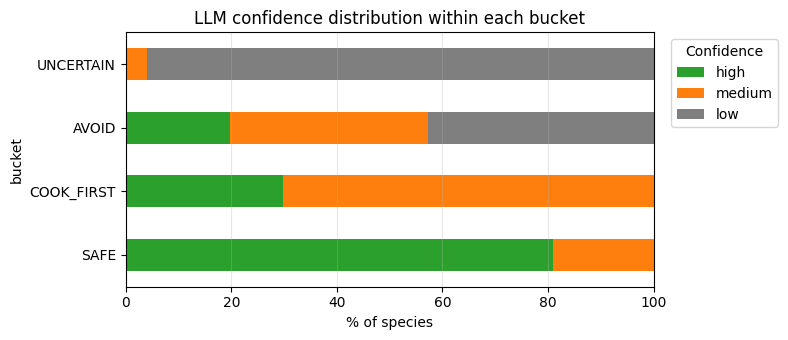

In [11]:
conf_pivot = pd.crosstab(edib['bucket'], edib['confidence']).reindex(BUCKET_ORDER, fill_value=0)
# Normalize to percentages within bucket
conf_pct = conf_pivot.div(conf_pivot.sum(axis=1), axis=0) * 100

print("LLM confidence per bucket (% within each bucket):")
print(conf_pct.round(1))

fig, ax = plt.subplots(figsize=(8, 3.5))
conf_pct[['high', 'medium', 'low']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#2ca02c', '#ff7f0e', '#7f7f7f'],
)
ax.set_xlabel('% of species')
ax.set_title('LLM confidence distribution within each bucket')
ax.legend(title='Confidence', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_DIR / 'confidence_per_bucket.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 8 — Key Takeaways for the Report

The analysis supports four claims to include in the final writeup:

1. **The 4-class scheme is balanced enough for classification.** Image-level distribution of roughly 12 / 20 / 55 / 13 (SAFE / COOK_FIRST / AVOID / UNCERTAIN) is more balanced than the raw 179-way species distribution (39x imbalance).

2. **Different genera present fundamentally different sub-problems.**
   - Mycena (~28% of all images) is **uniformly AVOID** — trivial to classify but of no research interest.
   - Amanita, Russula, Boletus have **mixed buckets** — these are where AL strategies should earn their advantage.
   - Russula is the dominant contributor to UNCERTAIN (25 of 25), making it the "research spotlight" genus.

3. **UNCERTAIN is a defensible epistemic category, not noise.** [Confirmed by Step 7: UNCERTAIN should be dominated by `low` LLM confidence.]

4. **AVOID hides internal heterogeneity.** Most AVOID species are mildly toxic or inedible (levels 1-2). Only 2 species in this dataset are `deadly` (level 5). This matters when framing the safety narrative — the system's primary value is distinguishing "worth eating" from "not worth eating", not life-saving emergency warnings.


In [12]:
# Save the enriched edibility map with bucket column for downstream use
enriched_path = ARTIFACTS_DIR / 'species_edibility_with_buckets.csv'
edib[['species', 'genus', 'edibility_raw', 'edibility_cooked',
      'toxicity_level', 'confidence', 'bucket', 'notes']].to_csv(enriched_path, index=False)
print(f"Saved enriched map: {enriched_path}")
print(f"(Contains the original columns plus the 'bucket' column used by Notebook 2)")

Saved enriched map: artifacts/species_edibility_with_buckets.csv
(Contains the original columns plus the 'bucket' column used by Notebook 2)
